<a href="https://colab.research.google.com/github/malikshahzaib263/neurofive-ml-track/blob/main/Week_4_Task_2_Random_Forest_vs_XGBoost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 4 – Machine Learning Fundamentals

# Task 2: Ensemble Learning — Random Forest vs XGBoost

### Neurofive Solutions – Machine Learning Track

**Author:** Shahzaib Arshad

---

## Project Overview

In this project, I compare two powerful ensemble learning algorithms, Random Forest and XGBoost, using the Telco Customer Churn dataset.

The performance of both ensemble models is compared with the Logistic Regression model used in an earlier task. I also analyze feature importance to understand which customer characteristics are most influential in predicting churn.

## Project Objectives

The objectives of this project are:

- Use the previously analyzed Telco Customer Churn dataset.
- Train a Logistic Regression baseline model.
- Train a Random Forest Classifier.
- Train an XGBoost Classifier.
- Compare the performance of all three models.
- Analyze feature importance from Random Forest and XGBoost.
- Understand how ensemble learning differs from single-model learning.
- Present the results in a clear comparison table.

In [1]:
!pip install xgboost

## Load the Dataset

The Telco Customer Churn dataset is uploaded into Google Colab. This dataset contains customer demographics, service details, billing information, and churn status.

In [5]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn (1).csv to WA_Fn-UseC_-Telco-Customer-Churn (1).csv


In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [9]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn (1).csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 7043
Number of columns: 21


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [13]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

## Data Cleaning

The `customerID` column is removed because it is only an identifier and does not contain useful predictive information.

In [14]:
df = df.drop(columns=["customerID"])

print("customerID removed successfully.")

customerID removed successfully.


In [15]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

,count
Churn,
0,5174
1,1869


In [16]:
print("Class Counts:")
print(df["Churn"].value_counts())

print("\nClass Percentages:")
print(
    (
        df["Churn"].value_counts(normalize=True)
        * 100
    ).round(2)
)

Class Counts:
Churn
0    5174
1    1869
Name: count, dtype: int64

Class Percentages:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


## Feature and Target Selection

The `Churn` column is used as the target variable. All remaining columns are used as input features.

In [17]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7043, 19)
Target shape: (7043,)


In [18]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical Columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## Train-Test Split

The dataset is divided into 80% training data and 20% testing data. Stratification is used so that the churn distribution remains similar in both sets.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (5634, 19)
Testing shape: (1409, 19)


In [20]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            )
        )
    ]
)

In [21]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

## Logistic Regression Baseline

Logistic Regression is used as the earlier single-model baseline. The ensemble models will be compared against this model using the same training and testing data.

In [22]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [23]:
logistic_model.fit(
    X_train,
    y_train
)

logistic_predictions = logistic_model.predict(
    X_test
)

In [24]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

print(f"Accuracy:  {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall:    {logistic_recall:.4f}")
print(f"F1-score:  {logistic_f1:.4f}")

Accuracy:  0.7381
Precision: 0.5043
Recall:    0.7834
F1-score:  0.6136


## Random Forest Classifier

Random Forest is an ensemble learning method that trains many Decision Trees on different subsets of the data. Their predictions are combined to produce a more stable and reliable final prediction.

In [25]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=10,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [26]:
random_forest_model.fit(
    X_train,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test
)

In [27]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")

Accuracy:  0.7637
Precision: 0.5406
Recall:    0.7299
F1-score:  0.6212


## XGBoost Classifier

XGBoost is a boosting algorithm that trains trees sequentially. Each new tree focuses on correcting the errors made by previous trees, allowing the model to gradually improve its predictions.

In [28]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                n_estimators=200,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss"
            )
        )
    ]
)

In [29]:
xgb_model.fit(
    X_train,
    y_train
)

xgb_predictions = xgb_model.predict(
    X_test
)

In [30]:
xgb_accuracy = accuracy_score(
    y_test,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test,
    xgb_predictions
)

xgb_recall = recall_score(
    y_test,
    xgb_predictions
)

xgb_f1 = f1_score(
    y_test,
    xgb_predictions
)

print(f"Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall:    {xgb_recall:.4f}")
print(f"F1-score:  {xgb_f1:.4f}")

Accuracy:  0.8070
Precision: 0.6700
Recall:    0.5374
F1-score:  0.5964


## Model Performance Comparison

The Logistic Regression baseline is compared with Random Forest and XGBoost using Accuracy, Precision, Recall, and F1-score.

In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall,
        xgb_recall
    ],
    "F1-score": [
        logistic_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7381,0.5043,0.7834,0.6136
1,Random Forest,0.7637,0.5406,0.7299,0.6212
2,XGBoost,0.8070,0.6700,0.5374,0.5964


In [32]:
best_model_row = comparison.loc[
    comparison["F1-score"].idxmax()
]

print("Best Model Based on F1-score:")
print(best_model_row)

Best Model Based on F1-score:
Model        Random Forest
Accuracy          0.763662
Precision         0.540594
Recall            0.729947
F1-score           0.62116
Name: 1, dtype: object


In [33]:
trained_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

encoded_features = (
    trained_preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(
        categorical_columns
    )
)

all_feature_names = np.concatenate([
    numerical_columns,
    encoded_features
])

print(
    "Total transformed features:",
    len(all_feature_names)
)

Total transformed features: 30


In [34]:
trained_rf = (
    random_forest_model
    .named_steps["classifier"]
)

rf_importances = trained_rf.feature_importances_

rf_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_importances
}).sort_values(
    "Importance",
    ascending=False
)

rf_importance_df.head(10)

,Feature,Importance
1,tenure,0.174647
3,TotalCharges,0.143211
2,MonthlyCharges,0.103936
25,Contract_Two year,0.100289
10,InternetService_Fiber optic,0.066101
28,PaymentMethod_Electronic check,0.049497
24,Contract_One year,0.041860
13,OnlineSecurity_Yes,0.035060
19,TechSupport_Yes,0.025069
26,PaperlessBilling_Yes,0.019449


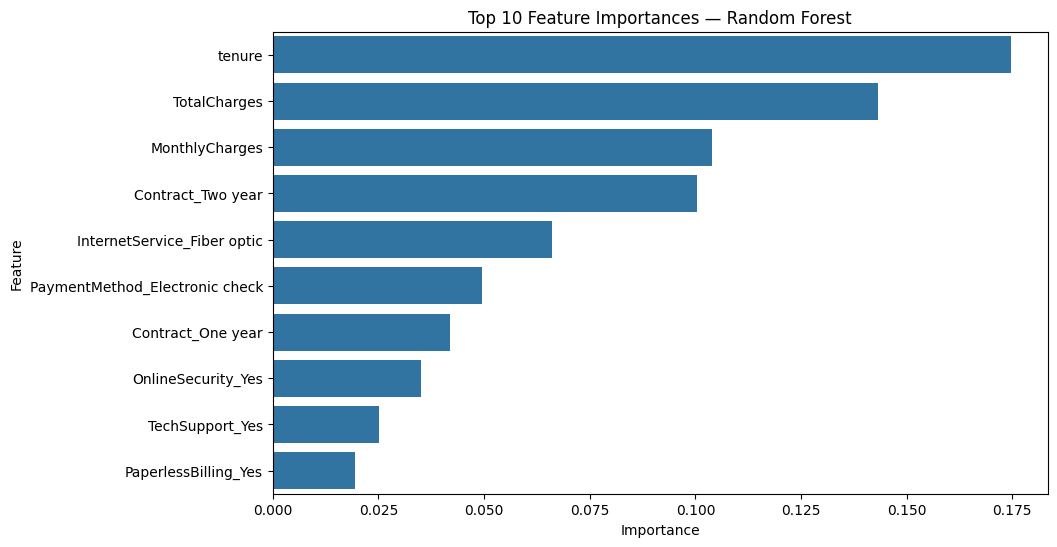

In [35]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=rf_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importances — Random Forest"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [36]:
trained_xgb = (
    xgb_model
    .named_steps["classifier"]
)

xgb_importances = trained_xgb.feature_importances_

xgb_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": xgb_importances
}).sort_values(
    "Importance",
    ascending=False
)

xgb_importance_df.head(10)

,Feature,Importance
10,InternetService_Fiber optic,0.231046
25,Contract_Two year,0.151281
12,OnlineSecurity_No internet service,0.088457
11,InternetService_No,0.077296
24,Contract_One year,0.061981
28,PaymentMethod_Electronic check,0.050664
1,tenure,0.046838
26,PaperlessBilling_Yes,0.030049
23,StreamingMovies_Yes,0.024702
13,OnlineSecurity_Yes,0.021799


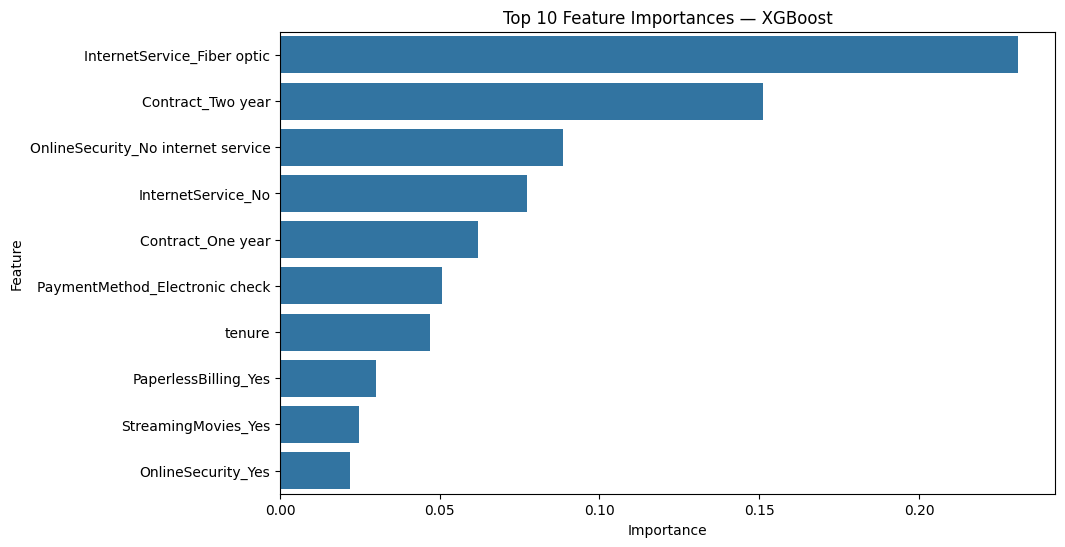

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=xgb_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Feature Importances — XGBoost"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

In [38]:
print("Random Forest Top 5 Features:")
print(
    rf_importance_df.head(5)
)

print("\nXGBoost Top 5 Features:")
print(
    xgb_importance_df.head(5)
)

Random Forest Top 5 Features:
                        Feature  Importance
1                        tenure    0.174647
3                  TotalCharges    0.143211
2                MonthlyCharges    0.103936
25            Contract_Two year    0.100289
10  InternetService_Fiber optic    0.066101

XGBoost Top 5 Features:
                               Feature  Importance
10         InternetService_Fiber optic    0.231046
25                   Contract_Two year    0.151281
12  OnlineSecurity_No internet service    0.088457
11                  InternetService_No    0.077296
24                   Contract_One year    0.061981


## Random Forest vs XGBoost

Random Forest builds many Decision Trees independently using different samples of the training data and combines their predictions through voting. XGBoost builds trees sequentially, where each new tree focuses on correcting errors made by previous trees. Random Forest mainly reduces variance by averaging multiple trees, while XGBoost improves performance through iterative error correction. As a result, XGBoost can often achieve stronger predictive performance, although it usually requires more careful parameter tuning.

## Conclusion

In this project, Logistic Regression, Random Forest, and XGBoost models were trained on the Telco Customer Churn dataset using the same train-test split. Their performance was compared using Accuracy, Precision, Recall, and F1-score. Feature importance analysis from Random Forest and XGBoost also showed which customer characteristics contributed most strongly to churn predictions. This project demonstrated how ensemble methods combine multiple models to produce more powerful and reliable machine learning predictions.